# **Segmentasi Tipe Pelanggan Berdasarkan Atribut RFM Menggunakan Metode K-Means Clustering**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

**Preprocessing data**

In [ ]:
df = df.dropna(subset=["CustomerID"])

In [ ]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [ ]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [ ]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

**Pembentukan Variabel RFM**

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "count",                                      # Frequency
    "TotalPrice": "sum"                                        # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

# 1. Tentukan fitur yang akan dibersihkan
features = ['Recency', 'Frequency', 'Monetary']

# 2. Gunakan metode IQR untuk Capping (Winsorizing)
# tidak menghapus data, tapi membatasi nilai maksimalnya agar tidak terlalu ekstrem
for col in features:
    Q1 = rfm[col].quantile(0.05) # Batas bawah (persentil 5)
    Q3 = rfm[col].quantile(0.95) # Batas atas (persentil 95)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Terapkan capping
    rfm[col] = rfm[col].clip(lower_limit, upper_limit)

print("Outlier telah ditangani dengan metode Capping.")
print(rfm.describe()) # Cek perubahan statistik deskriptifnya

print(rfm.head())

Outlier telah ditangani dengan metode Capping.
           Recency    Frequency      Monetary
count  4338.000000  4338.000000   4338.000000
mean     92.536422    84.070741   1532.883328
std     100.014169   118.738023   2408.815401
min       1.000000     1.000000      3.750000
25%      18.000000    17.000000    307.415000
50%      51.000000    41.000000    674.485000
75%     142.000000   100.000000   1661.740000
max     374.000000   779.375000  14436.143250
            Recency  Frequency     Monetary
CustomerID                                 
12346           326        1.0  14436.14325
12347             2      182.0   4310.00000
12348            75       31.0   1797.24000
12349            19       73.0   1757.55000
12350           310       17.0    334.40000


In [ ]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346 to 18287
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   float64
 2   Monetary   4338 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 135.6 KB


**Normalisasi Data**

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

**Penentuan Jumlah Klaster dan Klasterisasi K-Means**

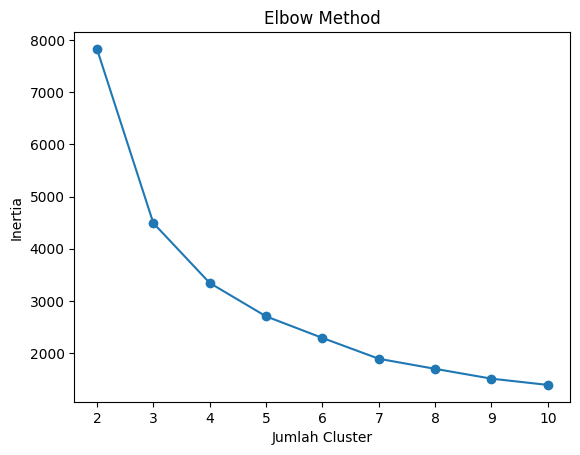

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

            Recency  Frequency     Monetary  Cluster
CustomerID                                          
12346           326        1.0  14436.14325        2
12347             2      182.0   4310.00000        1
12348            75       31.0   1797.24000        1
12349            19       73.0   1757.55000        1
12350           310       17.0    334.40000        0


In [ ]:
score = silhouette_score(rfm_scaled, rfm["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.5276078634766131


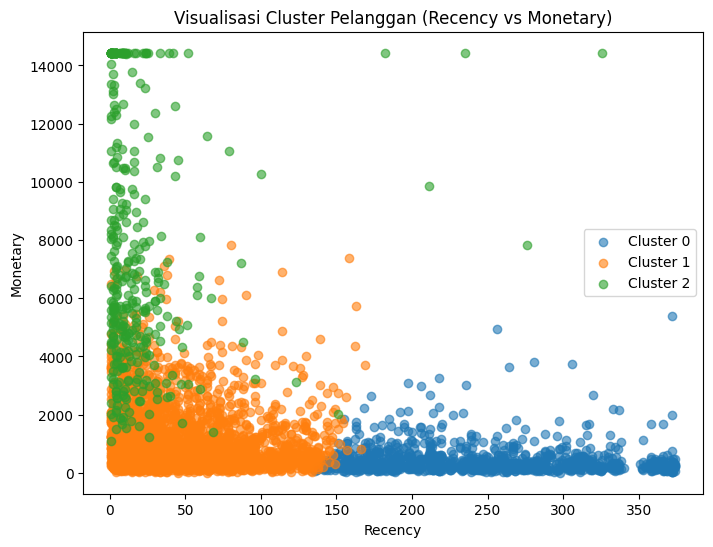

In [ ]:
plt.figure(figsize=(8,6))

for cluster in sorted(rfm["Cluster"].unique()):
    cluster_data = rfm[rfm["Cluster"] == cluster]
    plt.scatter(
        cluster_data["Recency"],
        cluster_data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Visualisasi Cluster Pelanggan (Recency vs Monetary)")
plt.legend()
plt.show()


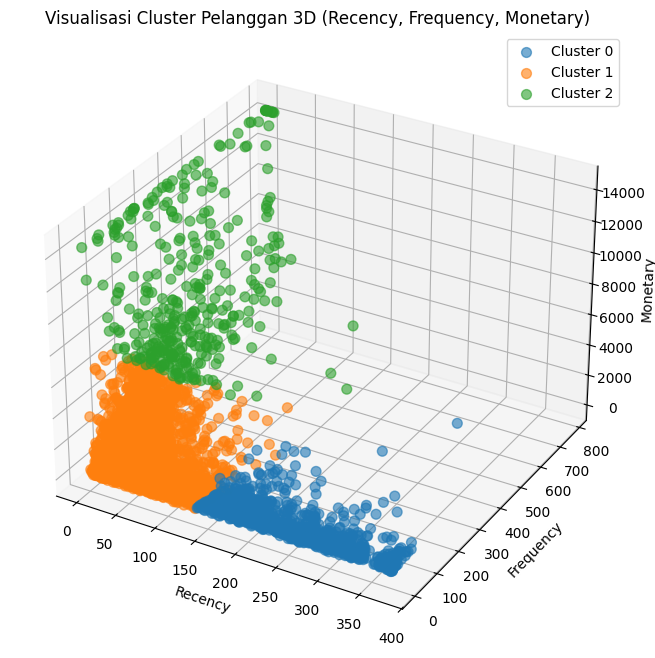

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in sorted(rfm["Cluster"].unique()):
    cluster_data = rfm[rfm["Cluster"] == cluster]
    ax.scatter(
        cluster_data["Recency"],
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6,
        s=50
    )

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

ax.set_title("Visualisasi Cluster Pelanggan 3D (Recency, Frequency, Monetary)")
ax.legend()

plt.show()

In [ ]:
rfm_output = rfm.reset_index()

print(rfm_output.head(10))

   CustomerID  Recency  Frequency     Monetary  Cluster
0       12346      326        1.0  14436.14325        2
1       12347        2      182.0   4310.00000        1
2       12348       75       31.0   1797.24000        1
3       12349       19       73.0   1757.55000        1
4       12350      310       17.0    334.40000        0
5       12352       36       85.0   2506.04000        1
6       12353      204        4.0     89.00000        0
7       12354      232       58.0   1079.40000        0
8       12355      214       13.0    459.40000        0
9       12356       23       59.0   2811.43000        1


In [ ]:
cluster_count = rfm_output["Cluster"].value_counts().sort_index()
print(cluster_count)

Cluster
0    1058
1    2917
2     363
Name: count, dtype: int64


In [ ]:
cluster_profile = rfm_output.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_profile)

            Recency   Frequency     Monetary
Cluster                                     
0        248.789225   26.306238   442.377610
1         45.069249   68.559479  1175.500519
2         18.559229  377.076791  7583.133200


/tmp/ipython-input-951481260.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Recency', data=rfm, ax=axes[0], palette='Set2')
/tmp/ipython-input-951481260.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Frequency', data=rfm, ax=axes[1], palette='Set2')
/tmp/ipython-input-951481260.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[2], palette='Set2')


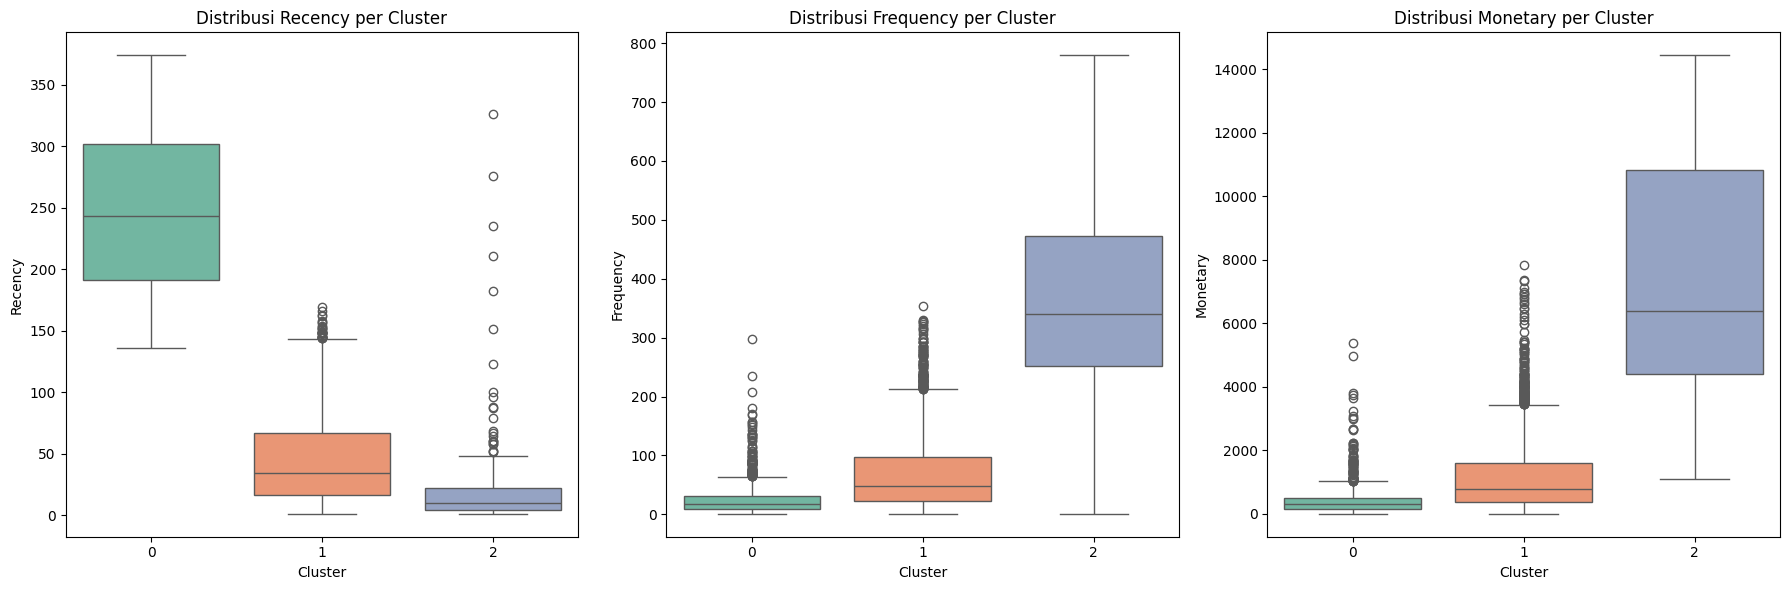

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.boxplot(x='Cluster', y='Recency', data=rfm, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Recency per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Recency')

sns.boxplot(x='Cluster', y='Frequency', data=rfm, ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Frequency per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Frequency')

sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[2], palette='Set2')
axes[2].set_title('Distribusi Monetary per Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Monetary')

plt.tight_layout()
plt.show()

| Cluster | Karakteristik RFM                                               | Interpretasi Pelanggan                                             | Kategori Pelanggan                 | Rekomendasi                                                           |
| ------- | --------------------------------------------------------------- | ------------------------------------------------------------------ | ---------------------------------- | --------------------------------------------------------------------- |
| **0**   | Recency tinggi, Frequency rendah, Monetary rendah               | Sudah lama tidak bertransaksi, jarang belanja, nilai belanja kecil | **Pelanggan Low Value / Pelanggan pasif** | Perlu strategi reaktivasi seperti diskon, reminder, atau promo khusus |
| **1**   | Recency sedang, Frequency sedang, Monetary menengah             | Cukup aktif dan masih berkontribusi                                | **Pelanggan Mid Value / Pelanggan aktif reguler**        | Pertahankan dengan program loyalitas dan penawaran upselling          |
| **2**   | Recency rendah, Frequency sangat tinggi, Monetary sangat tinggi | baru bertransaksi, sangat sering, nilai belanja besar     | **Pelanggan High Value / Loyal**   | Prioritaskan dengan reward eksklusif dan layanan khusus               |
